# **Preparación de entorno de trabajo**
---
## **1. Python**
Para este curso y las sesiones de laboratorio se utilizará el lenguaje **Python** (v3.10+). En particular utilizaremos **Jupyter Notebook** para el desarrollo de los laboratorios.
<div>
<center>
<img src="https://drive.google.com/uc?export=view&id=1D_QOz3WMkQjp20dBQ-wxNgfmF2Yh7x6P" width="300"/>
</center>
</div>

### 1.1. Estructura del código

Se espera que para la escritura de su código, se apeguen a alguno de estos dos tipos de paradigmas: **funcional** u **orientado a objetos**. La definición de variables, nombres de funciones, etc. deben seguir el estilo de escritura o convención de nombramiento ***snake_case***.
```
# OOP
class ImageProcessor:
    def __init__(self, image_path):
        self.image = self.load_image(image_path)

    def load_image(self, image_path):
        ...
        ...

class SimilCalc:
    @staticmethod
    def cosine_similarity(a, b):
        ...
        ...

processor = ImageProcessor('my/path')
similarity = SimilCalc.cosine_similarity(array_a, array_b)
```
```
# Funcional
def load_image(image_path):
    ...
    ...

def cosine_similarity(a, b):
    ...
    ...

images = load_image('my/path')
similarity_matrix = cosine_similarity(array_a, array_b)
```

### 1.2. Documentación
Crucial para la revisión de los laboratorios es la documentación de su código. Toda clase, método, función y bloque de código suficientemente complejo debe ir correctamente documentado.
***Recomendación:*** apegarse a convención *PEP 257 Docstring*.

Para la escritura en lenguaje natural se puede utilizar bien español o inglés, pero se exige **no mezclar idiomas**.
```
# Ejemplo de documentación
def load_image(image_path):
    """
    Loads an image from the specified path.

    Args:
        image_path (str): Path to the image file.
    Returns:
        np.ndarray: Loaded image as a NumPy array.
    """
    ...
    ...
```
```
# Ejemplo de documentación
class ImageProcessor:
    """
    A class for handling image processing.

    Attributes:
        image (np.ndarray): The loaded image as a NumPy array.
    """
    ...
    ...
```

**No es necesario** comentar operaciones simples o bloques de código que se explican por sí solos.

## **2. Entornos de trabajo**
### 2.1. Ambientes virtuales
Es buena práctica que cuenten con un entorno de trabajo específico, donde dispongan de las bibliotecas y variables de entorno que deseen, para cada entrega del curso. Esto puede lograrse mediante el uso de ambientes virtuales.

```
# "-m" corre el módulo instalado "venv" como un script por sí mismo
# crear ambiente virtual en directorio "directorio objetivo"
python -m venv "directorio objetivo"

# crear ambiente virtual en directorio actual
python -m venv .
```

Para comenzar a trabajar, siempre activar el ambiente virtual:
```
cd "directorio objetivo"
./Scripts/activate
```
o
```
cd "directorio objetivo"
source /bin/activate
```
Al terminar, es buena práctica desactivar el ambiente virtual (`deactivate`) para que no hayan errores si se utiliza el mismo directorio para trabajar después, pero también se puede cerrar la terminal simplemente.

Normalmente el ambiente virtual viene con pip instalado, por lo que se pueden listar todas las bibliotecas de antemano en un archivo de requerimientos ("requirements.txt") y correr:
```
pip install -r requirements.txt
```

<big>**Alternativa: Conda (anaconda/miniconda)**</big>

Es un package manager (como pip) y también maneja ambientes virtuales. Contiene las bibliotecas que normalmente utilizaríamos en ciencia de datos o ML. La instalación es distinta en Windows y Linux por lo que mejor es visitar la página directamente.

Para crear un ambiente virtual y aislado, lo mejor es crearlo a partir de un archivo de configuración "env.yml":
```
name: env_name_here
dependencies:
    - python==3.10
    - conda-forge::openslide
    - pip
    - pip:
        - pandas
        - matplotlib
        - scikit-learn
        - scipy
```

Y luego:
```
conda env create -f env.yml
conda activate env_name_here
# terminar de trabajar...
conda deactivate env_name_here
```

# **Recordatorio y manejo básico de bibliotecas**
---
## Numpy
Manejo matricial, creación e indexación de objetos de n dimensionalidad

In [ ]:
# Crear una matriz
import numpy as np

a = np.array([1, 2, 3])
print(a.shape)

a = np.array([
    [1, 2, 3],
    [4, 5, 6]
    ])
print(a.shape)


a = np.array([
[
   [1, 2, 3],
   [4, 5, 6],
   [7, 8, 9]
],
[
  [10, 11, 12],
  [13, 14, 15],
  [16, 17, 18]
],
[
   [19, 20, 21],
   [22, 23, 24],
   [25, 26, 27]
]
])
print(a.shape)

(3,)
(2, 3)
(3, 3, 3)


In [ ]:
# Obtener el valor RGB para el pixel (0, 0)
print('print 1\n', np.array([a[0, 0, 0], a[1, 0, 0], a[2, 0, 0]]),'\n')

# Obtener el canal R de la imagen
print('print 2\n', a[0, :, :], '\n')

# Suprimir todos los tonos de verde sin modificar el array original
no_green = a.copy()
no_green[1, :, :] = 0
print('print 3\n', no_green, '\n')

print 1
 [ 1 10 19] 

print 2
 [[1 2 3]
 [4 5 6]
 [7 8 9]] 

print 3
 [[[ 1  2  3]
  [ 4  5  6]
  [ 7  8  9]]

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[19 20 21]
  [22 23 24]
  [25 26 27]]] 



## Visualizar imágenes con Matplotlib (Pyplot)

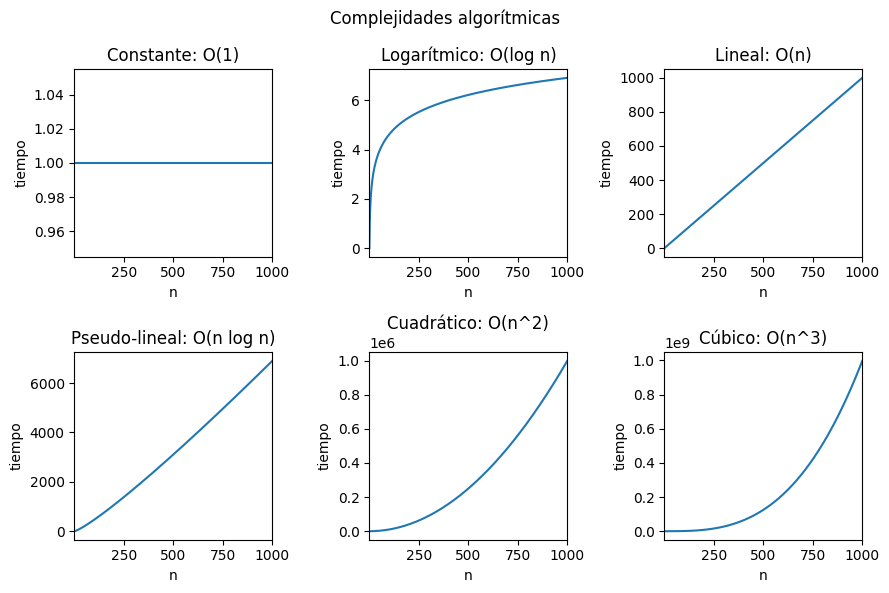

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_rows, n_cols = 2, 3
x = np.arange(1, 1000)

# Lista que contiene tuplas compuestas por:
# (string, arreglo NumPy)
complexity_functions = [
    ("Constante: O(1)", np.ones_like(x)),
    ("Logarítmico: O(log n)", np.log(x)),
    ("Lineal: O(n)", x),
    ("Pseudo-lineal: O(n log n)", x * np.log(x)),
    ("Cuadrático: O(n^2)", x**2),
    ("Cúbico: O(n^3)", x**3),
]

# Definir subplots
# fig es básicamente el lienzo en que se dibujarán los gráficos
# axes es un arreglo de tamaño n_rows * n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 6))

# Matriz axes -> volverla 1d
axes = axes.flatten()

# Se itera sobre la lista complexity_functions según el índice i.
# Se van a desempaquetar las tuplas internas en las variables (label, value)
for i, (label, value) in enumerate(complexity_functions):
    axes[i].set_title(label)
    axes[i].plot(x, value)

    axes[i].set_xlabel('n')
    axes[i].set_ylabel('tiempo')
    axes[i].set_xlim([1, 1000])

# también se puede agregar un título a todo el subplot
plt.suptitle("Complejidades algorítmicas")
plt.tight_layout() # Evita sobrelape de leyendas, títulos y nombres de ejes
plt.show()